In [1]:
# import libarys
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.cluster import KMeans

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [5]:
# import data
df=pd.read_csv(r"C:\Users\24kl\Downloads\Nassau Candy Distributor (2).csv")

In [6]:
# read data
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [8]:
df.describe()

,Row ID,Customer ID,Sales,Units,Gross Profit,Cost
count,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000,10194.000000
mean,5097.500000,134468.961154,13.908537,3.791838,9.166451,4.742087
std,2942.898656,20231.483007,11.341020,2.228317,6.643740,5.061647
min,1.000000,100006.000000,1.250000,1.000000,0.250000,0.600000
25%,2549.250000,117212.000000,7.200000,2.000000,4.900000,2.400000
50%,5097.500000,133550.000000,10.800000,3.000000,7.470000,3.600000
75%,7645.750000,152051.000000,18.000000,5.000000,12.250000,5.700000
max,10194.000000,192314.000000,260.000000,14.000000,130.000000,130.000000


In [9]:
df.shape

(10194, 18)

In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost'],
      dtype='object')

In [11]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Division          0
Region            0
Product ID        0
Product Name      0
Sales             0
Units             0
Gross Profit      0
Cost              0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
# Phase 2 Feature Engineering

In [15]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d-%m-%Y")
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d-%m-%Y")

df["Lead_Time"]=(df["Ship Date"]-df["Order Date"]).dt.days

In [16]:
df["Profit_Margin"]=df["Gross Profit"]/df["Sales"]

In [17]:
df["Cost_per_Unit"]=df["Cost"]/df["Units"]

In [18]:
df["Sales_per_Unit"]=df["Sales"]/df["Units"]

In [19]:
factory_dict={

"Wonka Bar - Nutty Crunch Surprise":"Lot's O' Nuts",

"Wonka Bar - Fudge Mallows":"Lot's O' Nuts",

"Wonka Bar -Scrumdiddlyumptious":"Lot's O' Nuts",

"Wonka Bar - Milk Chocolate":"Wicked Choccy's",

"Wonka Bar - Triple Dazzle Caramel":"Wicked Choccy's",

"Laffy Taffy":"Sugar Shack",

"SweeTARTS":"Sugar Shack",

"Nerds":"Sugar Shack",

"Fun Dip":"Sugar Shack",

"Fizzy Lifting Drinks":"Sugar Shack",

"Everlasting Gobstopper":"Secret Factory",

"Hair Toffee":"The Other Factory",

"Lickable Wallpaper":"Secret Factory",

"Wonka Gum":"Secret Factory",

"Kazookles":"The Other Factory"

}

In [20]:
df["Factory"]=df["Product Name"].map(factory_dict)

In [21]:
# Phase 4 Add Factory Coordinates

factory_location={

"Lot's O' Nuts":(32.881893,-111.768036),

"Wicked Choccy's":(32.076176,-81.088371),

"Sugar Shack":(48.11914,-96.18115),

"Secret Factory":(41.446333,-90.565487),

"The Other Factory":(35.1175,-89.971107)

}

In [22]:
df["Factory_Latitude"]=df["Factory"].map(lambda x:factory_location[x][0])

In [23]:
df["Factory_Longitude"]=df["Factory"].map(lambda x:factory_location[x][1])

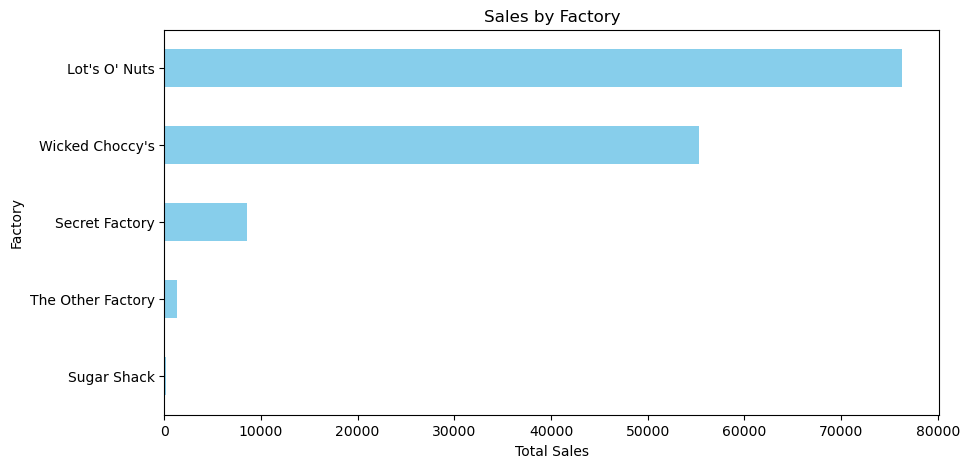

In [24]:
# Phase 5 EDA

#1. Sales by Factory
plt.figure(figsize=(10,5))
df.groupby("Factory")["Sales"].sum().sort_values().plot(kind="barh", color="skyblue")
plt.title("Sales by Factory")
plt.xlabel("Total Sales")
plt.ylabel("Factory")
plt.show()

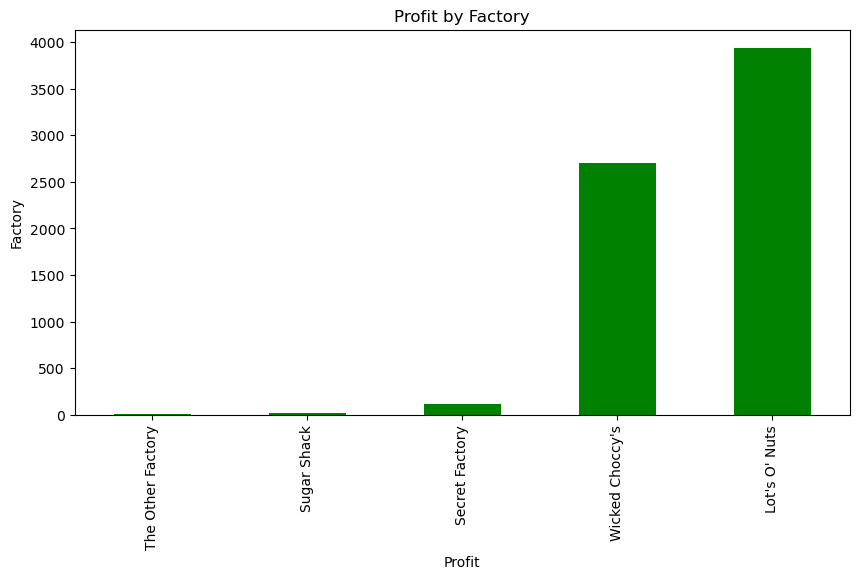

In [31]:
# 2. Profit by Factory

plt.figure(figsize=(10,5))
df.groupby("Factory")["Profit_Margin"].sum().sort_values().plot(kind="bar", color="green")
plt.title("Profit by Factory")
plt.xlabel("Profit")
plt.ylabel("Factory")
plt.show()

In [29]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead_Time', 'Profit_Margin',
       'Cost_per_Unit', 'Sales_per_Unit', 'Factory', 'Factory_Latitude',
       'Factory_Longitude'],
      dtype='object')

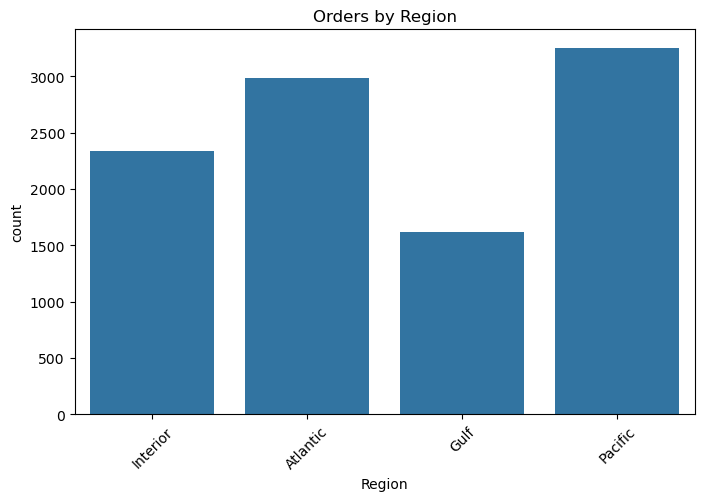

In [32]:
# 3. Orders by Region

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Region")
plt.title("Orders by Region")
plt.xticks(rotation=45)
plt.show()

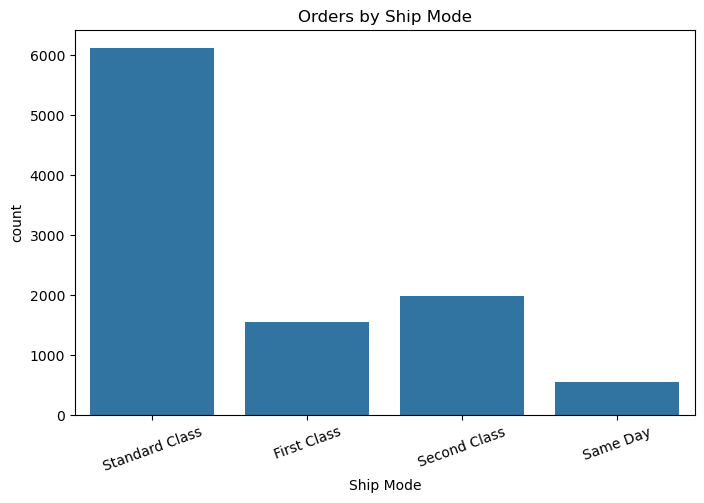

In [33]:
# 4. Orders by Ship Mode

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Ship Mode")
plt.title("Orders by Ship Mode")
plt.xticks(rotation=20)
plt.show()

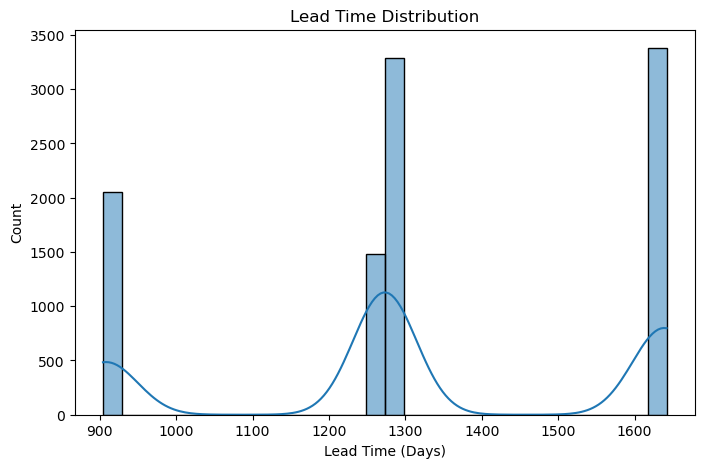

In [34]:
# 5. Lead Time Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["Lead_Time"], bins=30, kde=True)
plt.title("Lead Time Distribution")
plt.xlabel("Lead Time (Days)")
plt.show()

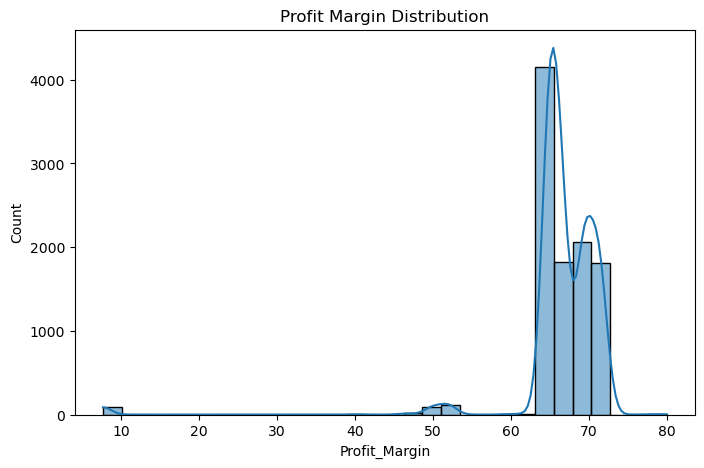

In [36]:
# 6. Profit Margin Distribution

df["Profit_Margin"]=(df["Gross Profit"]/df["Sales"])*100

plt.figure(figsize=(8,5))
sns.histplot(df["Profit_Margin"], bins=30, kde=True)
plt.title("Profit Margin Distribution")
plt.show()

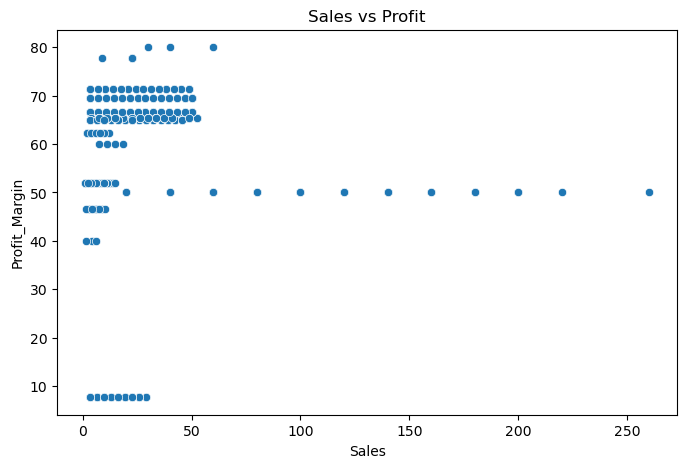

In [38]:
# 7. Sales vs Profit

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Sales", y="Profit_Margin")
plt.title("Sales vs Profit")
plt.show()

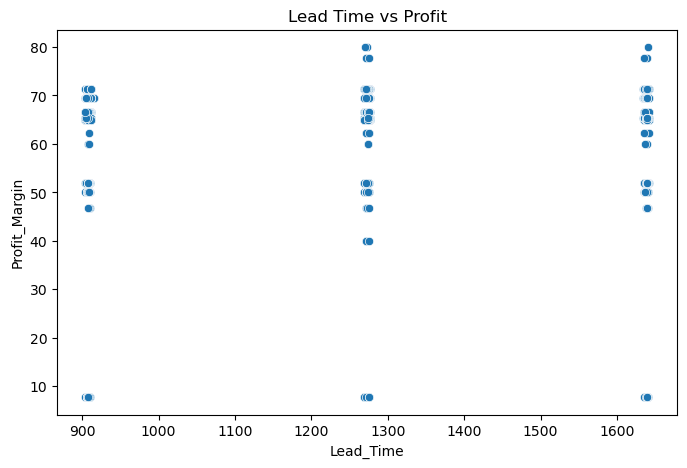

In [40]:
# 8. Lead Time vs Profit

plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Lead_Time", y="Profit_Margin")
plt.title("Lead Time vs Profit")
plt.show()

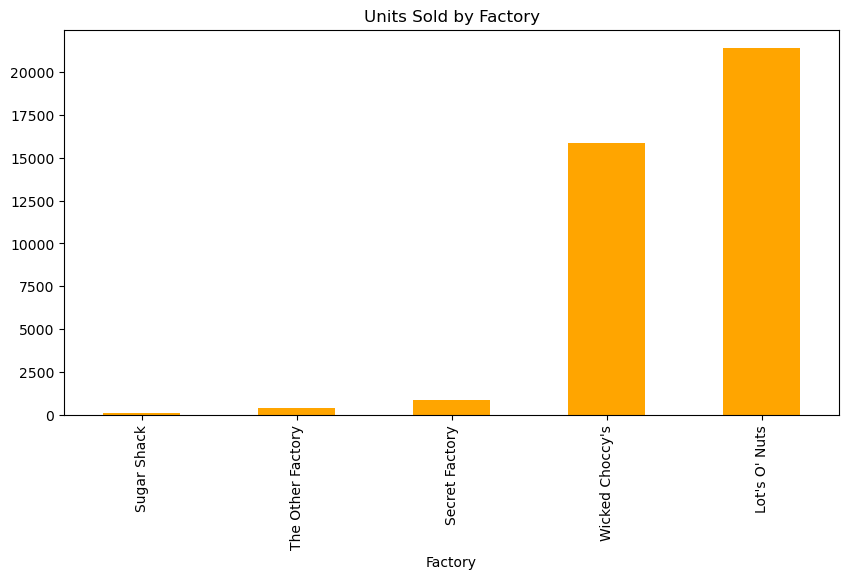

In [44]:
# 9. Units Sold by Factory

plt.figure(figsize=(10,5))

df.groupby("Factory")["Units"].sum().sort_values().plot(
    kind="bar",
    color="orange"
)

plt.title("Units Sold by Factory")
plt.show()

In [42]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Country/Region', 'City', 'State/Province',
       'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name',
       'Sales', 'Units', 'Gross Profit', 'Cost', 'Lead_Time', 'Profit_Margin',
       'Cost_per_Unit', 'Sales_per_Unit', 'Factory', 'Factory_Latitude',
       'Factory_Longitude'],
      dtype='object')

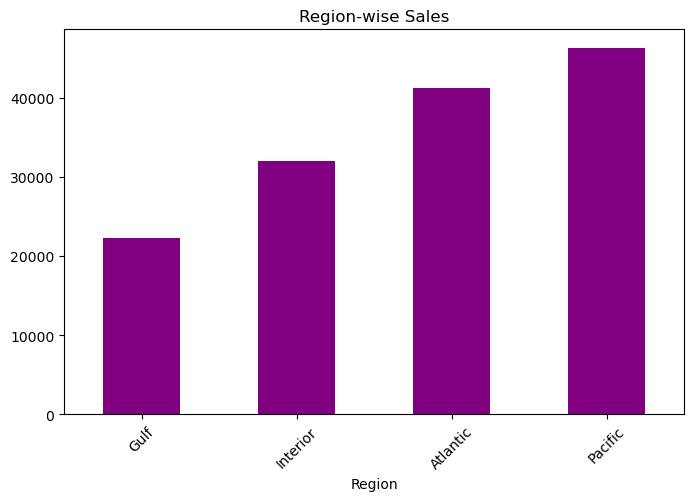

In [45]:
# 10. Region-wise Sales
plt.figure(figsize=(8,5))

df.groupby("Region")["Sales"].sum().sort_values().plot(
    kind="bar",
    color="purple"
)

plt.title("Region-wise Sales")
plt.xticks(rotation=45)
plt.show()

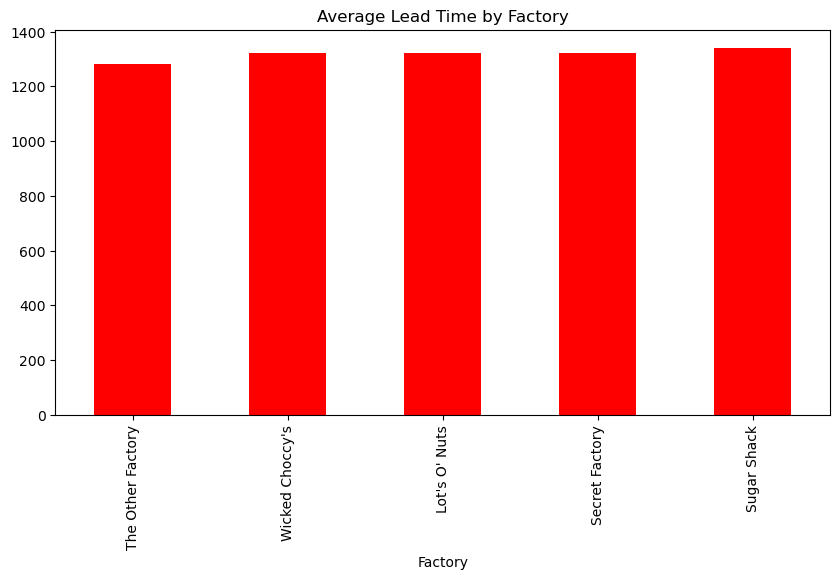

In [47]:
# 11. Factory-wise Average Lead Time

plt.figure(figsize=(10,5))

df.groupby("Factory")["Lead_Time"].mean().sort_values().plot(
    kind="bar",
    color="red"
)

plt.title("Average Lead Time by Factory")
plt.show()

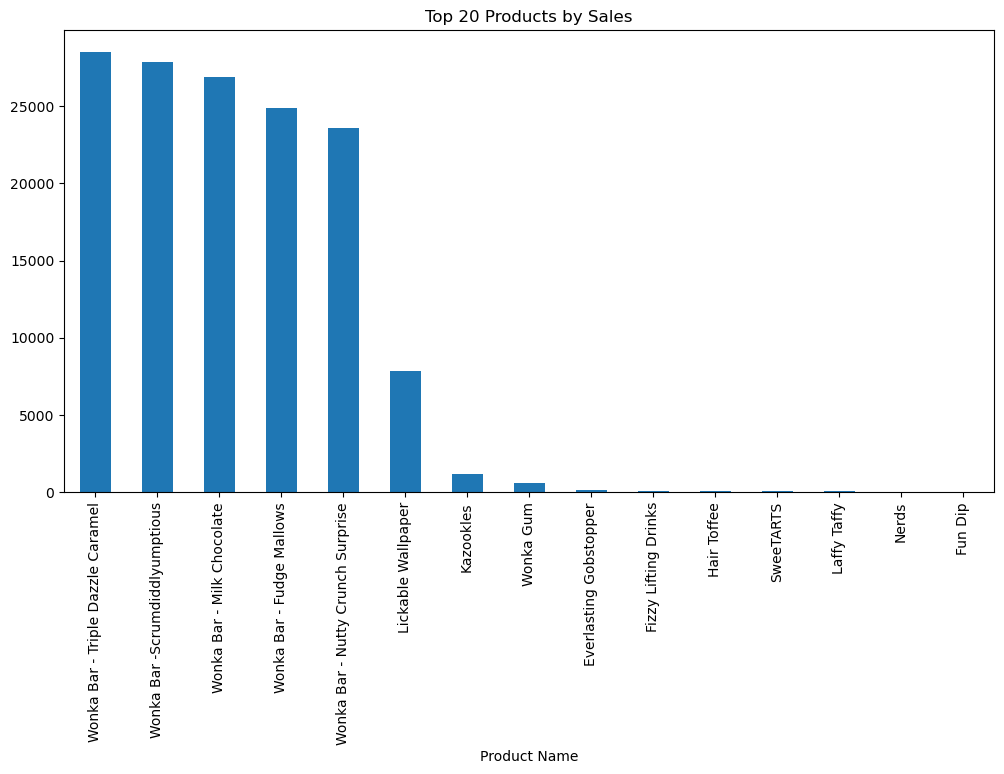

In [48]:
# 12. Product-wise Sales (Top 20)

plt.figure(figsize=(12,6))

df.groupby("Product Name")["Sales"].sum()\
.sort_values(ascending=False)\
.head(20)\
.plot(kind="bar")

plt.title("Top 20 Products by Sales")
plt.xticks(rotation=90)
plt.show()

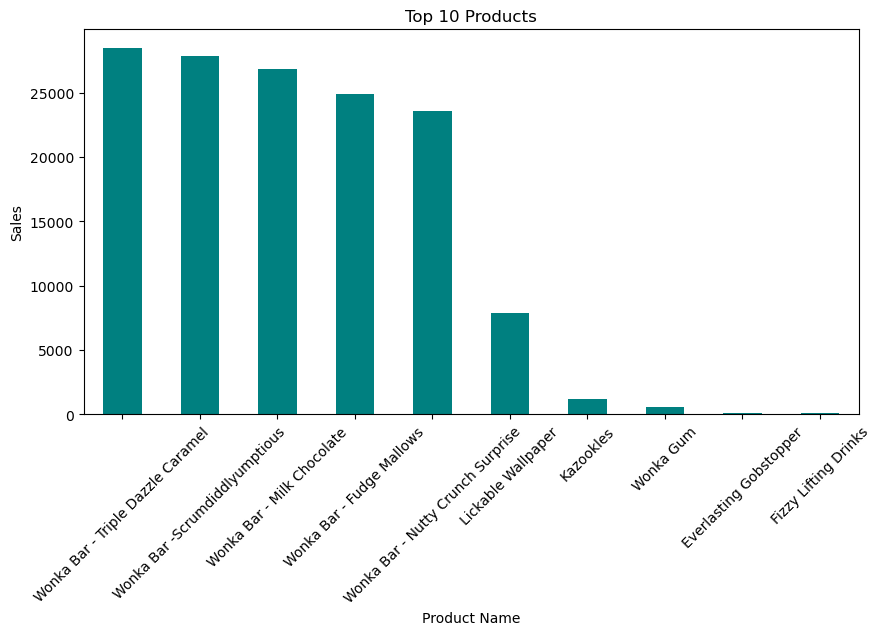

In [49]:
# 13. Top 10 Products

top10=df.groupby("Product Name")["Sales"].sum()\
.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))

top10.plot(kind="bar",color="teal")

plt.title("Top 10 Products")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

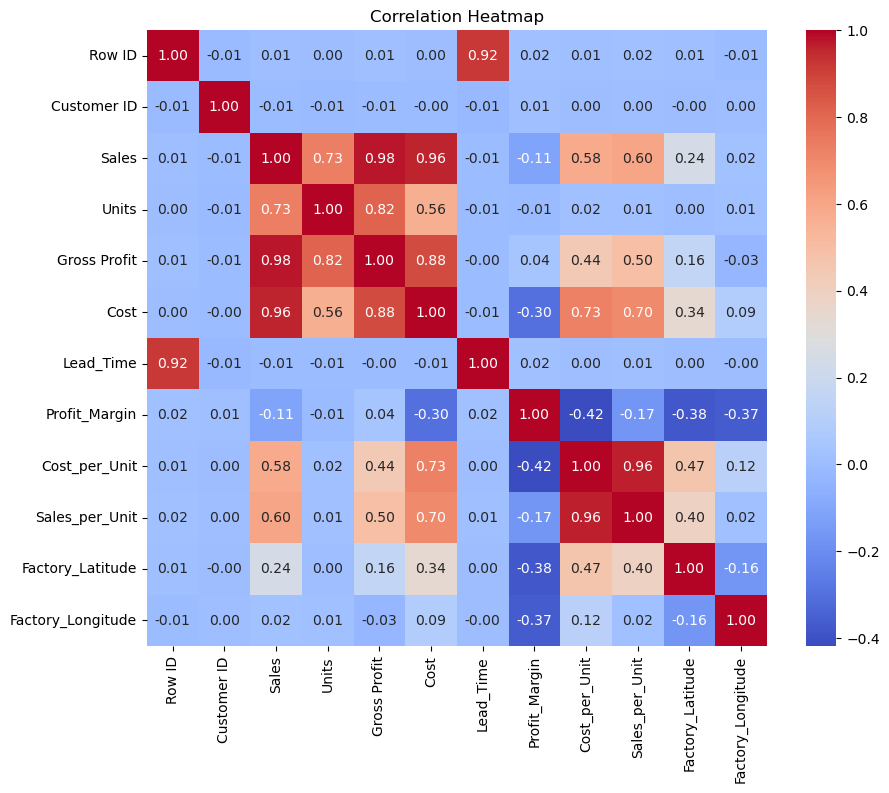

In [50]:
# 14. Correlation Heatmap

plt.figure(figsize=(10,8))

corr=df.select_dtypes(include=["int64","float64"]).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

In [51]:
# Phase 6 Data Encoding

In [52]:
encoder=LabelEncoder()

cols=["Region","Ship Mode","Factory","Division","Product Name"]

for i in cols:
    df[i]=encoder.fit_transform(df[i])

In [53]:
# Phase 7 Feature Selection

y=df["Lead_Time"]

In [54]:
X=df[[
"Sales",
"Units",
"Gross Profit",
"Cost",
"Ship Mode",
"Factory",
"Division",
"Region",
"Product Name"
]]

In [55]:
# Phase 8 Scaling

scaler=StandardScaler()

X=scaler.fit_transform(X)

In [56]:
# Phase 9 Train Test Split

X_train,X_test,y_train,y_test=train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [57]:
# Phase 10 Model Building

#Linear Regression
lr=LinearRegression()

lr.fit(X_train,y_train)

pred_lr=lr.predict(X_test)

In [58]:
# Random Forest

rf=RandomForestRegressor()

rf.fit(X_train,y_train)

pred_rf=rf.predict(X_test)

In [59]:
# Gradient Boosting

gb=GradientBoostingRegressor()

gb.fit(X_train,y_train)

pred_gb=gb.predict(X_test)

In [71]:
factories = df["Factory"].unique()

print(factories)

[4 0 1 3 2]


In [72]:
product = "Wonka Bar - Milk Chocolate"

In [73]:
product_data = df[df["Product Name"] == product].copy()

In [115]:
current_factory = product_data["Factory"].iloc[0]

print(current_factory)

4


In [116]:
results = []

In [117]:
for factory in factories:

    temp = product_data.copy()

    temp["Factory"] = factory

    prediction = rf.predict(temp[X.columns])

    avg_lead_time = prediction.mean()

    results.append([factory, avg_lead_time])

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [76]:
scenario = pd.DataFrame(
    results,
    columns=["Factory","Predicted Lead Time"]
)

scenario

,Factory,Predicted Lead Time


In [77]:
scenario = scenario.sort_values(
    by="Predicted Lead Time"
)

scenario

,Factory,Predicted Lead Time


In [118]:
products = df["Product Name"].unique()

recommendations = []

for product in products:

    product_data = df[df["Product Name"] == product].copy()

    for factory in factories:

        temp = product_data.copy()

        temp["Factory"] = factory

        prediction = rf.predict(temp[X.columns])

        recommendations.append([
            product,
            factory,
            prediction.mean()
        ])

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [79]:
recommendations = pd.DataFrame(
    recommendations,
    columns=[
        "Product",
        "Factory",
        "Predicted Lead Time"
    ]
)

recommendations.head()

,Product,Factory,Predicted Lead Time


In [80]:
best_factory = recommendations.loc[
    recommendations.groupby("Product")["Predicted Lead Time"].idxmin()
]

best_factory

,Product,Factory,Predicted Lead Time


In [81]:
# Phase 11 Evaluation

def evaluate(y_test,pred):

    print("RMSE",np.sqrt(mean_squared_error(y_test,pred)))

    print("MAE",mean_absolute_error(y_test,pred))

    print("R2",r2_score(y_test,pred))

In [82]:
evaluate(y_test,pred_rf)

RMSE 276.87758711843287
MAE 224.61019338187006
R2 -0.08399959721655303


In [83]:
kmeans=KMeans(n_clusters=4,random_state=42)

df["Cluster"]=kmeans.fit_predict(X)

In [84]:
# Phase 12 Clustering

In [85]:
kmeans=KMeans(n_clusters=4,random_state=42)

df["Cluster"]=kmeans.fit_predict(X)

In [86]:
cluster_summary = df.groupby("Cluster").agg({
    "Lead_Time": "mean",
    "Sales": "mean",
    "Gross Profit": "mean",
    "Units": "mean"
})

print(cluster_summary)

           Lead_Time       Sales  Gross Profit     Units
Cluster                                                 
0        1320.879609    9.837612      6.537251  2.837151
1        1321.037425   24.058275     16.082047  6.735030
2        1299.926471  101.764706     51.147059  5.132353
3        1321.039236    9.127845      6.089368  2.620547


In [ ]:
Current Factory

↓

Move Product

↓

Predict Lead Time

↓

Compare Profit

↓

Recommend Best Factory

In [98]:
#Phase 14 Recommendation Engine

recommendations = []

In [102]:
feature_columns = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost",
    "Ship Mode",
    "Region",
    "Division",
    "Product Name",
    "Factory"
]

In [107]:
X

array([[-0.65328348, -0.80416133, -0.7445646 , ..., -0.18107091,
         0.35124039, -0.54693164],
       [-0.56510367, -0.80416133, -0.64220759, ..., -0.18107091,
         0.35124039,  0.62388338],
       [-0.3032096 , -0.3553701 , -0.25535829, ..., -0.18107091,
         0.35124039,  0.03847587],
       ...,
       [-0.27411026, -0.3553701 , -0.25084254, ..., -0.18107091,
         1.17644078,  1.20929089],
       [ 1.08826794,  1.43979481,  1.20172387, ..., -0.18107091,
        -1.2991604 ,  0.62388338],
       [-0.27411026, -0.3553701 , -0.25084254, ..., -0.18107091,
        -1.2991604 ,  1.20929089]], shape=(10194, 9))

In [108]:
print(type(X))

<class 'numpy.ndarray'>


In [110]:
feature_columns = [
    "Sales",
    "Units",
    "Gross Profit",
    "Cost",
    "Ship Mode",
    "Region",
    "Division",
    "Product Name",
    "Factory"
]

In [111]:
temp = temp[feature_columns]

In [112]:
temp[X.columns]

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [103]:
predicted = rf.predict(temp[feature_columns]).mean()

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [122]:
products = df["Product Name"].unique()
factories = df["Factory"].unique()

for product in products:

    product_data = df[df["Product Name"] == product].copy()

    current_factory = product_data["Factory"].iloc[0]

    current_lead = product_data["Lead_Time"].mean()

    current_profit = product_data["Gross Profit"].mean()

    best_factory = current_factory
    best_prediction = current_lead

    for factory in factories:

        temp = product_data.copy()

        temp["Factory"] = factory

        predicted = rf.predict(temp[X.columns]).mean()

        if predicted < best_prediction:
            best_prediction = predicted
            best_factory = factory

    improvement = ((current_lead - best_prediction) / current_lead) * 100

AttributeError: 'numpy.ndarray' object has no attribute 'columns'

In [123]:
print(type(X))

<class 'numpy.ndarray'>


In [124]:
    if improvement >= 20:
        risk = "Low"
    elif improvement >= 10:
        risk = "Medium"
    else:
        risk = "High"

NameError: name 'improvement' is not defined

In [125]:
profit_impact = current_profit

In [126]:
    recommendations.append([
        product,
        current_factory,
        best_factory,
        round(current_lead,2),
        round(best_prediction,2),
        round(improvement,2),
        risk,
        round(profit_impact,2)
    ])

NameError: name 'improvement' is not defined

In [127]:
recommendation_df = pd.DataFrame(
    recommendations,
    columns=[
        "Product",
        "Current Factory",
        "Recommended Factory",
        "Current Lead Time",
        "Predicted Lead Time",
        "Improvement %",
        "Risk",
        "Profit Impact"
    ]
)

In [128]:
recommendation_df.head()

,Product,Current Factory,Recommended Factory,Current Lead Time,Predicted Lead Time,Improvement %,Risk,Profit Impact


In [129]:
recommendation_df = recommendation_df.sort_values(
    by="Improvement %",
    ascending=False
)

recommendation_df.head(10)

,Product,Current Factory,Recommended Factory,Current Lead Time,Predicted Lead Time,Improvement %,Risk,Profit Impact


In [ ]:
# 13 KPIs

In [130]:
# total sales
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 141783.63


In [131]:
# total sales
total_profit = df["Gross Profit"].sum()
print("Total Profit:", total_profit)

Total Profit: 93442.79999999999


In [132]:
# avreage lead time

avg_lead_time = df["Lead_Time"].mean()
print("Average Lead Time:", avg_lead_time)

Average Lead Time: 1320.8418677653522


In [133]:
# Average lead time

avg_profit_margin = df["Profit_Margin"].mean()
print("Average Profit Margin:", avg_profit_margin)

Average Profit Margin: 66.51404480694819


In [134]:
# lead time reduction % 

lead_time_reduction = (
    (recommendation_df["Current Lead Time"] -
     recommendation_df["Predicted Lead Time"]).mean()
    /
    recommendation_df["Current Lead Time"].mean()
) * 100

print("Lead Time Reduction %:", lead_time_reduction)

Lead Time Reduction %: nan


In [135]:
# estimated saveing 

estimated_savings = (
    recommendation_df["Current Lead Time"] -
    recommendation_df["Predicted Lead Time"]
).sum() * 100

print("Estimated Savings:", estimated_savings)

Estimated Savings: 0


In [136]:
# order proceed

orders_processed = df["Order ID"].nunique()

print("Orders Processed:", orders_processed)

Orders Processed: 8549


In [137]:
# recommendation covrage 

recommendation_coverage = (
    recommendation_df["Product"].nunique()
    /
    df["Product Name"].nunique()
) * 100

print("Recommendation Coverage:", recommendation_coverage)

Recommendation Coverage: 0.0


In [140]:
average_improvement = recommendation_df["Improvement %"].mean()

print("Average Improvement %:", average_improvement)

Average Improvement %: nan


In [141]:
# High-Risk Reassignments

high_risk = (
    recommendation_df["Risk"] == "High"
).sum()

print("High-Risk Reassignments:", high_risk)

High-Risk Reassignments: 0


In [142]:
# kpi summary table

kpi_summary = {
    "Total Sales": total_sales,
    "Total Profit": total_profit,
    "Average Lead Time": avg_lead_time,
    "Average Profit Margin": avg_profit_margin,
    "Lead Time Reduction %": lead_time_reduction,
    "Estimated Savings": estimated_savings,
    "Orders Processed": orders_processed,
    "Recommendation Coverage": recommendation_coverage,
    "High-Risk Reassignments": high_risk,
    "Average Improvement %": average_improvement
}

kpi_df = pd.DataFrame(
    kpi_summary.items(),
    columns=["KPI", "Value"]
)

print(kpi_df)

                       KPI          Value
0              Total Sales  141783.630000
1             Total Profit   93442.800000
2        Average Lead Time    1320.841868
3    Average Profit Margin      66.514045
4    Lead Time Reduction %            NaN
5        Estimated Savings       0.000000
6         Orders Processed    8549.000000
7  Recommendation Coverage       0.000000
8  High-Risk Reassignments       0.000000
9    Average Improvement %            NaN
